In [37]:
!pip install -q "transformers>=4.40.0" accelerate datasets pillow qwen-vl-utils

In [43]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [1]:
%cd /content/drive/MyDrive/RL/RL_Scene_Graphs
%ls

/content/drive/MyDrive/RL/RL_Scene_Graphs
datasets/              MLLM_Eval.ipynb      mllm_pipeline.py
Image_Data_Prep.ipynb  MLLM_Pipeline.ipynb


### Dataset and Prompt

In [2]:
from datasets import load_from_disk, load_dataset
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
import torch
import re
import json
from typing import Tuple, Any, Dict
from PIL import Image
import matplotlib.pyplot as plt
from pprint import pprint
import ast

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
def load_sample(ds, index: int = 0):
    """Load a VG sample from a HuggingFace-disk dataset.
    """
    sample = ds[index]
    return {
        "image": sample["image"].convert("RGB"),
        "objects": sample["objects"],
        "relationships": sample["relationships"],
        "prompt_open": sample.get("prompt_open", ""),
        "prompt_close": sample.get("prompt_close", "")
    }

def build_messages(image, prompt: str):
    """Build the chat-style message list the Qwen2-VL processor expects.

    This mirrors the repository: the user message contains an image entry and a text entry.
    """
    return [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]

In [5]:
psg_val = load_from_disk("./datasets/psg_test_sg")
print(psg_val)

Dataset({
    features: ['image_id', 'image', 'objects', 'relationships'],
    num_rows: 2186
})


{'image': <PIL.Image.Image image mode=RGB size=640x464 at 0x7EB16C2E9C40>,
 'objects': '[{"id": "person.1", "bbox": [3, 199, 234, 419]}, {"id": '
            '"person.2", "bbox": [190, 3, 474, 391]}, {"id": "person.3", '
            '"bbox": [0, 142, 51, 238]}, {"id": "person.4", "bbox": [546, 56, '
            '640, 295]}, {"id": "banana.5", "bbox": [604, 384, 640, 456]}, '
            '{"id": "banana.6", "bbox": [536, 396, 639, 464]}, {"id": '
            '"banana.7", "bbox": [562, 401, 627, 448]}, {"id": "banana.8", '
            '"bbox": [499, 324, 573, 381]}, {"id": "banana.9", "bbox": [594, '
            '358, 640, 388]}, {"id": "apple.10", "bbox": [426, 397, 461, '
            '425]}, {"id": "apple.11", "bbox": [424, 370, 460, 391]}, {"id": '
            '"apple.12", "bbox": [305, 408, 343, 449]}, {"id": "apple.13", '
            '"bbox": [390, 384, 429, 417]}, {"id": "apple.14", "bbox": [447, '
            '371, 497, 405]}, {"id": "apple.15", "bbox": [356, 399, 381, '
         

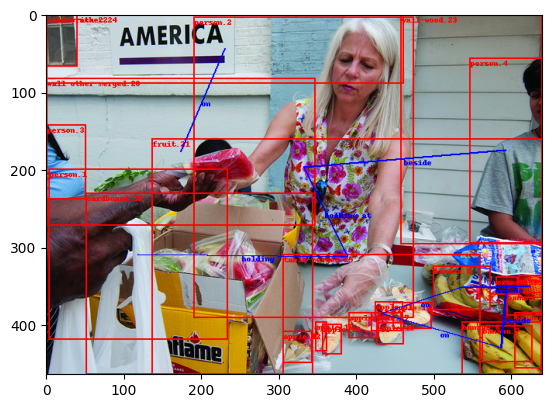

In [6]:
## sample the psg dataset
sample_psg = load_sample(psg_val, index=1)
pprint(sample_psg)
plt.imshow(sample_psg["image"])
plt.show()

In [7]:
def get_class(obj: str):
  cls = obj.split(".")[0]
  return cls

all_classes = []
all_predicates = []

# plot distribution of objects and predicates
for idx in range(len(psg_val)):
    sample = load_sample(psg_val, index=idx)
    objects = ast.literal_eval(sample['objects'])
    relationships = ast.literal_eval(sample['relationships'])

    all_classes.extend([get_class(obj['id']) for obj in objects])
    all_predicates.extend([rel['predicate'] for rel in relationships])



all_classes = list(set(all_classes))
all_predicates = list(set(all_predicates))

print(all_classes[:5])
print(all_predicates[:5])


['gravel', 'teddy bear', 'river', 'horse', 'wall-brick']
['sitting on', 'chasing', 'attached to', 'opening', 'biting']


In [8]:
print("Total unique classes: ", len(all_classes))
print("Total unique predicates: ", len(all_predicates))

Total unique classes:  133
Total unique predicates:  56


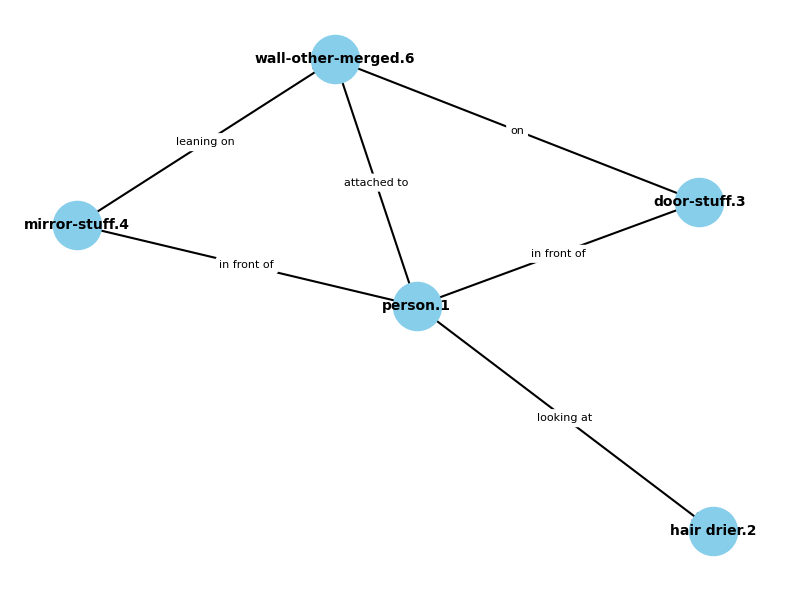

Centrality Score: {'person.1': 0.16666666666666666, 'hair drier.2': 0.0, 'mirror-stuff.4': 0.0, 'wall-other-merged.6': 0.0, 'door-stuff.3': 0.0}


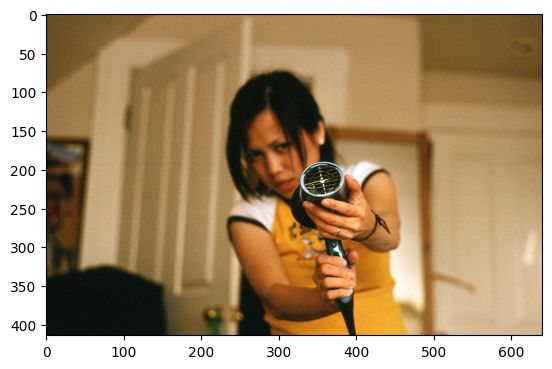

In [9]:
# plot triplets of relationships

def plot_graph(rels):
    # rels: list of {"subject": "...", "predicate": "...", "object": "..."}
    G = nx.DiGraph()
    for rel in rels:
        G.add_edge(rel["subject"], rel["object"], label=rel["predicate"])

    # Layout and figure size
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, k=0.8, seed=0)  # k controls spacing

    # Draw nodes and edges
    nx.draw_networkx_nodes(G, pos, node_color="#87CEEB", node_size=1200)
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=15, width=1.5)

    # Node labels
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold",
        horizontalalignment="center",
        verticalalignment="center",
    )

    # Edge labels (predicates)
    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=8,
        label_pos=0.5,
        rotate=False,  # easier to read
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

    centrality_score = nx.betweenness_centrality(G)
    print("Centrality Score:", centrality_score)

sample = load_sample(psg_val, index=1000)
plot_graph(ast.literal_eval(sample['relationships']))

plt.imshow(sample["image"])
plt.show()

### Model

In [11]:
# model_name = "Qwen/Qwen2-VL-2B-Instruct"
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"
processor = AutoProcessor.from_pretrained(model_name)
# model = Qwen2VLForConditionalGeneration.from_pretrained(
#     model_name,
#     torch_dtype="auto",
#     device_map="auto"
# )

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

print("DEVICE = ", model.device)
model.eval()




preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

DEVICE =  cpu


Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLUAc

#### Generation

In [16]:
# ---------- Build messages, inputs ----------
# experimenting
import sys
sys.path.append('/content/drive/MyDrive/RL/RL_Scene_Graphs')

import generate_pipeline

SYSTEM_PROMPT = (
    "A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant "
    "first thinks about the reasoning process in the mind and then provides the user with the answer. The reasoning "
    "process and answer are enclosed within <think> </think> and <answer> </answer> tags, respectively, i.e., "
    "<think> reasoning process here </think><answer> answer here </answer>"
)


ModuleNotFoundError: No module named 'generate_pipeline'